In [1]:
import os, pandas as pd, numpy as np, matplotlib.pyplot as plt
os.chdir(os.path.expanduser("~/growth-marketing-analytics"))
ga = pd.read_parquet("data/processed/ga_sessions.parquet")
ga["new_visitor"] = ga.visit_number == 1
OUT = "module_2_google_analytics/outputs/"
print(ga.shape)

(903653, 20)


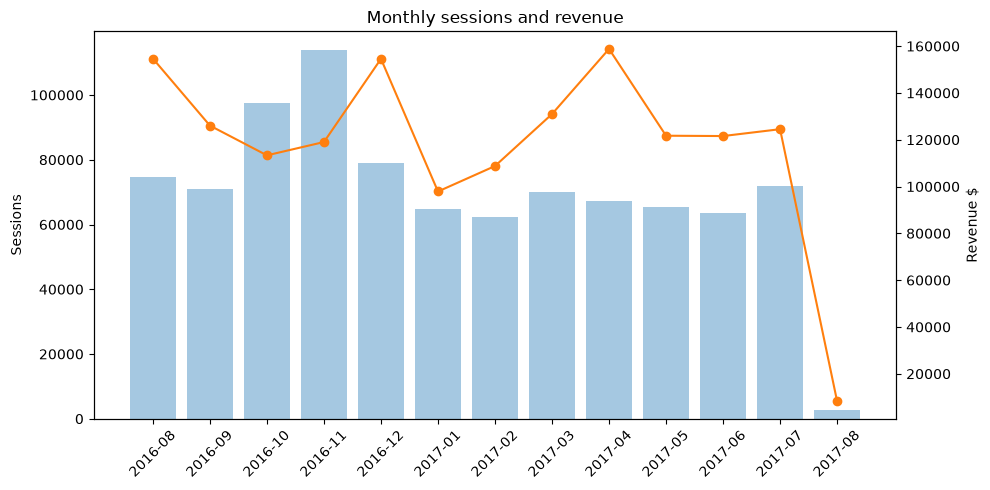

,sessions,buying,orders,revenue,cvr_%,aov
month,,,,,,
2016-08,74759,1145,1241,154666.56,1.53,124.63
2016-09,71032,870,904,126031.24,1.22,139.42
2016-10,97506,872,919,113329.07,0.89,123.32
2016-11,113972,919,955,119013.87,0.81,124.62
2016-12,79124,1395,1450,154557.93,1.76,106.59
2017-01,64694,697,713,97877.79,1.08,137.28
2017-02,62192,708,733,108756.52,1.14,148.37
2017-03,69931,883,993,130964.27,1.26,131.89
2017-04,67126,928,959,158788.80,1.38,165.58


In [2]:
ga["month"] = ga.date.dt.to_period("M")
mt = ga.groupby("month").agg(
    sessions=("session_id","count"),
    buying=("transactions", lambda x: (x>0).sum()),
    orders=("transactions","sum"),
    revenue=("revenue","sum"))
mt["cvr_%"] = mt.buying / mt.sessions * 100
mt["aov"] = mt.revenue / mt.orders
mt = mt.round(2)
mt.to_csv(OUT + "monthly_trend.csv")

fig, ax1 = plt.subplots(figsize=(10,5))
ax1.bar(mt.index.astype(str), mt.sessions, alpha=0.4, label="Sessions")
ax1.set_ylabel("Sessions")
ax2 = ax1.twinx()
ax2.plot(mt.index.astype(str), mt.revenue, marker="o", color="C1", label="Revenue")
ax2.set_ylabel("Revenue $")
ax1.set_title("Monthly sessions and revenue")
plt.setp(ax1.get_xticklabels(), rotation=45)
plt.tight_layout(); plt.savefig(OUT + "monthly_trend.png", dpi=150); plt.show()
mt

In [3]:
cp = ga[ga.campaign != "(not set)"].groupby("campaign").agg(
    sessions=("session_id","count"),
    buying=("transactions", lambda x: (x>0).sum()),
    revenue=("revenue","sum"))
cp["cvr_%"] = cp.buying / cp.sessions * 100
cp["revenue_per_session"] = cp.revenue / cp.sessions
cp = cp.sort_values("sessions", ascending=False).round(2)
cp.to_csv(OUT + "campaign_performance.csv")
print("Share of sessions with a tagged campaign: {:.1%}".format((ga.campaign != "(not set)").mean()))
cp.head(10)

Share of sessions with a tagged campaign: 3.1%


,sessions,buying,revenue,cvr_%,revenue_per_session
campaign,,,,,
Data Share Promo,16403,9,597.38,0.05,0.04
AW - Dynamic Search Ads Whole Site,6213,138,10787.36,2.22,1.74
AW - Accessories,5327,98,13997.55,1.84,2.63
AW - Electronics,74,0,0.00,0.0,0.00
AW - Apparel,32,0,0.00,0.0,0.00
All Products,4,0,0.00,0.0,0.00
Data Share,1,0,0.00,0.0,0.00


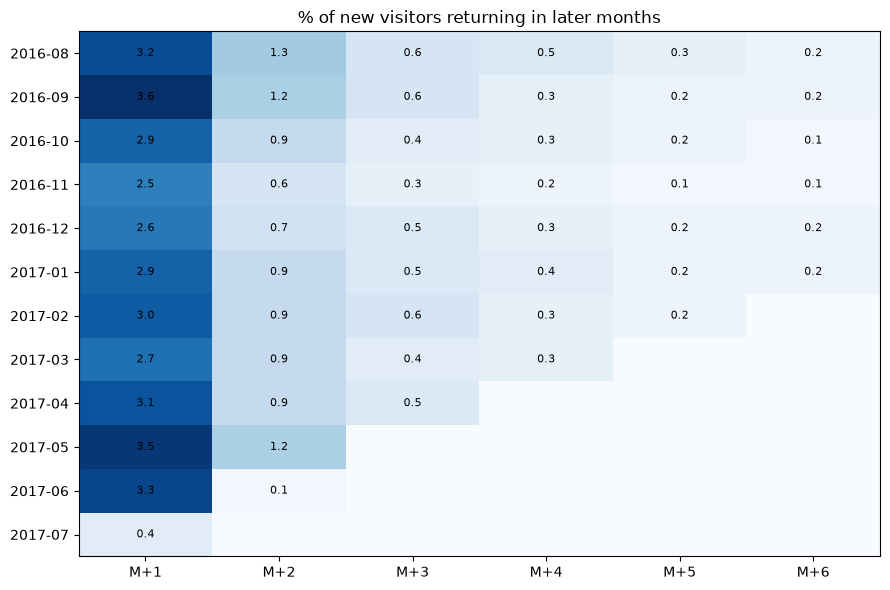

age,0,1,2,3,4,5,6
2016-08,100.0,3.2,1.3,0.6,0.5,0.3,0.2
2016-09,100.0,3.6,1.2,0.6,0.3,0.2,0.2
2016-10,100.0,2.9,0.9,0.4,0.3,0.2,0.1
2016-11,100.0,2.5,0.6,0.3,0.2,0.1,0.1
2016-12,100.0,2.6,0.7,0.5,0.3,0.2,0.2
2017-01,100.0,2.9,0.9,0.5,0.4,0.2,0.2
2017-02,100.0,3.0,0.9,0.6,0.3,0.2,0.0
2017-03,100.0,2.7,0.9,0.4,0.3,0.0,0.0
2017-04,100.0,3.1,0.9,0.5,0.0,0.0,0.0
2017-05,100.0,3.5,1.2,0.0,0.0,0.0,0.0


In [4]:
first = ga.loc[ga.groupby("visitor_id").date.idxmin(), ["visitor_id","visit_number"]]
true_new = first[first.visit_number == 1].visitor_id
v = ga[ga.visitor_id.isin(true_new)].copy()

v["m"] = v.date.dt.year * 12 + v.date.dt.month
v["cohort_m"] = v.groupby("visitor_id").m.transform("min")
v["age"] = v.m - v.cohort_m

tab = v.groupby(["cohort_m","age"]).visitor_id.nunique().unstack(fill_value=0)
ret = tab.div(tab[0], axis=0) * 100
ret.index = [f"{(m-1)//12}-{(m-1)%12+1:02d}" for m in ret.index]
ret = ret.iloc[:-1, :7].round(1)
ret.to_csv(OUT + "cohort_retention.csv")

fig, ax = plt.subplots(figsize=(9,6))
data = ret.iloc[:, 1:].values
im = ax.imshow(data, cmap="Blues", aspect="auto")
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        if not np.isnan(data[i,j]) and data[i,j] > 0:
            ax.text(j, i, f"{data[i,j]:.1f}", ha="center", va="center", fontsize=8)
ax.set_xticks(range(data.shape[1])); ax.set_xticklabels([f"M+{k}" for k in range(1, data.shape[1]+1)])
ax.set_yticks(range(len(ret))); ax.set_yticklabels(ret.index)
ax.set_title("% of new visitors returning in later months")
plt.tight_layout(); plt.savefig(OUT + "cohort_retention.png", dpi=150); plt.show()
ret

In [5]:
b = ga[ga.transactions > 0].groupby("visitor_id").agg(
    buying_sessions=("session_id","count"),
    revenue=("revenue","sum"))
repeat = b.buying_sessions > 1
print(f"""
Buyers: {len(b):,}
Repeat purchase rate: {repeat.mean():.1%}
Revenue from repeat buyers: {b[repeat].revenue.sum()/b.revenue.sum():.1%}
Avg revenue per buyer (12 months): ${b.revenue.mean():.2f}
Avg revenue per repeat buyer: ${b[repeat].revenue.mean():.2f}
Avg revenue per one-time buyer: ${b[~repeat].revenue.mean():.2f}
""")


Buyers: 10,022
Repeat purchase rate: 9.7%
Revenue from repeat buyers: 39.8%
Avg revenue per buyer (12 months): $153.67
Avg revenue per repeat buyer: $630.96
Avg revenue per one-time buyer: $102.46

